# Corrected CNN v3 / LWCNN Results Notebook

This notebook recomputes the thesis results for the uploaded **drone_detection_cnn_v3.py** model only. It targets the saved checkpoint:

`/content/drive/MyDrive/drone_audio_processed/model_lwcnn_drone_binary.keras`

It intentionally **does not load any CNN-Transformer / v2 checkpoints**, so it will not trigger the `AttentionPooling` custom-layer error.

The notebook fixes the main evaluation issues:

1. **No random augmentation during evaluation** by default. Training augmentation and evaluation are separated.
2. **Threshold sweep is computed explicitly** over many thresholds, not just 0.5 and 0.3.
3. **External clip scores use `max(window probabilities)` by default**, matching the thesis wording that a clip is positive if any 0.5 s window is sufficiently confident.
4. **Predictions are saved once and reused**, so all tables, confusion matrices, AUC values, and threshold-sweep values come from the same probability arrays.
5. **External labels are parsed explicitly** from `DRONE_`, `BACKGROUND_`, and `HELICOPTER_` file prefixes instead of a loose substring rule.

Run all cells from top to bottom in Colab. The notebook does **not retrain** the model; it evaluates the saved CNN v3 checkpoint.


## Added check: full LWCNN threshold table to 0.95

This edited version keeps your original corrected CNN v3 / LWCNN evaluation pipeline, but adds a report-ready threshold table from **0.05 to 0.95** in 0.05 increments.

It uses the model already specified in this notebook:

`/content/drive/MyDrive/drone_audio_processed/model_lwcnn_drone_binary.keras`

The table is generated from the same saved probability arrays as the confusion matrices, so the values should remain consistent.

In [1]:
# Colab setup
!pip -q install datasets librosa numpy scikit-learn tensorflow pandas matplotlib tqdm

In [2]:
import os
import glob
import zipfile
import requests
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
from tqdm.auto import tqdm

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    precision_recall_fscore_support,
    accuracy_score,
    ConfusionMatrixDisplay,
)

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.backend.clear_session()
try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print('Determinism warning:', e)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as e:
            print('GPU setup warning:', e)

print('TensorFlow:', tf.__version__)
print('GPU devices:', gpus)

Mounted at /content/drive
TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Paths and evaluation configuration

Change only these cells if your Drive folder or preferred model checkpoint is different.

In [3]:
OUT_DIR = Path('/content/drive/MyDrive/drone_audio_processed')
CACHE_PATH = OUT_DIR / 'waveform_0.50s_hop0.25s_recordsplit.npz'

# CNN v3 / LWCNN only. Do not include CNN-Transformer v2 checkpoints here.
MODEL_PATHS = {
    'CNN_v3_LWCNN': OUT_DIR / 'model_lwcnn_drone_binary.keras',
}

# Primary thesis protocol.
CLIP_AGGREGATION = 'max'  # 'max' matches thesis wording. Options: 'max', 'mean', 'p95', 'top3_mean'

THRESHOLDS = np.unique(np.round(np.r_[
    np.arange(0.01, 1.00, 0.01),
    [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.75, 0.95]
], 4))

# Feature settings copied from the uploaded CNN v3 code.
SR_TARGET = 16000
WIN_S = 0.5
HOP_S = 0.25
N_MELS = 64
N_FFT = 512
HOP_LENGTH = 128
FMAX = 8000
TOP_DB = 80
BATCH = 64

RESULTS_DIR = OUT_DIR / ('corrected_cnn_v3_results_' + datetime.now().strftime('%Y%m%d_%H%M%S'))
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print('Results will be saved to:', RESULTS_DIR)


Results will be saved to: /content/drive/MyDrive/drone_audio_processed/corrected_cnn_v3_results_20260514_152348


## Important

This notebook is for **CNN v3 / LWCNN only**. The previous `AttentionPooling` error came from accidentally trying to load `model_cnntransformer_v2_improved.keras`, which is not part of the uploaded CNN v3 script.

## 2. Utility functions

In [4]:
def load_keras_model(path: Path):
    """Load a Keras .keras model without compiling it."""
    try:
        return tf.keras.models.load_model(path, compile=False, safe_mode=False)
    except TypeError:
        return tf.keras.models.load_model(path, compile=False)


def sigmoid_np(x):
    x = np.asarray(x, dtype=np.float32)
    return 1.0 / (1.0 + np.exp(-x))


def get_target_frames(model):
    """Infer the time-frame dimension from a loaded model input shape."""
    shape = model.input_shape
    if isinstance(shape, list):
        shape = shape[0]
    if len(shape) != 4:
        raise ValueError(f'Expected model input shape (None, mel, frames, channel), got {shape}')
    target_mels, target_frames, channels = shape[1], shape[2], shape[3]
    if target_mels not in (None, N_MELS):
        raise ValueError(f'Model expects {target_mels} mel bins, but notebook uses {N_MELS}.')
    if channels not in (None, 1):
        raise ValueError(f'Model expects {channels} channels, but notebook uses 1.')
    if target_frames is None:
        target_frames = librosa.feature.melspectrogram(
            y=np.zeros(int(round(WIN_S * SR_TARGET)), dtype=np.float32),
            sr=SR_TARGET, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH,
            fmax=FMAX, power=2.0
        ).shape[1]
    return int(target_frames)


def log_mel_db(y, sr):
    y = np.asarray(y, dtype=np.float32)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH,
        fmax=FMAX, power=2.0
    )
    return librosa.power_to_db(mel, ref=1.0, top_db=TOP_DB).astype(np.float32)


def match_time_frames(mel, target_frames):
    """Crop or pad the time axis so the mel shape matches the loaded model."""
    if mel.shape[1] == target_frames:
        return mel
    if mel.shape[1] > target_frames:
        return mel[:, :target_frames]
    pad_width = target_frames - mel.shape[1]
    return np.pad(mel, ((0, 0), (0, pad_width)), mode='edge')


def mel_to_model_array(mel, target_frames):
    """Per-sample z-score normalisation, matching the original model input pipeline."""
    mel = match_time_frames(mel, target_frames)
    mel = mel[..., None].astype(np.float32)
    return ((mel - np.mean(mel)) / (np.std(mel) + 1e-6)).astype(np.float32)


def windows_all(y, sr, win_s=WIN_S, hop_s=HOP_S):
    """Extract all overlapping windows. Short clips are centred by zero padding for deterministic evaluation."""
    y = np.asarray(y, dtype=np.float32)
    win = int(round(win_s * sr))
    hop = int(round(hop_s * sr))

    if len(y) <= win:
        out = np.zeros(win, dtype=np.float32)
        start = (win - len(y)) // 2
        out[start:start + len(y)] = y
        return [out]

    return [y[start:start + win] for start in range(0, len(y) - win + 1, hop)]


def waves_to_model_batch(waves, target_frames):
    return np.stack([
        mel_to_model_array(log_mel_db(w, SR_TARGET), target_frames)
        for w in waves
    ]).astype(np.float32)


def predict_waveforms(model, waves, target_frames, batch_size=BATCH, desc='Predicting windows'):
    """Predict probabilities from waveform windows with no random augmentation."""
    probs = []
    for start in tqdm(range(0, len(waves), batch_size), desc=desc):
        batch_waves = waves[start:start + batch_size]
        X = waves_to_model_batch(batch_waves, target_frames)
        logits = model.predict(X, batch_size=batch_size, verbose=0).ravel()
        probs.append(sigmoid_np(logits))
    return np.concatenate(probs).astype(np.float32)


def aggregate_clip_probs(window_probs, method='max'):
    p = np.asarray(window_probs, dtype=np.float32)
    if len(p) == 0:
        return np.nan
    if method == 'max':
        return float(np.max(p))
    if method == 'mean':
        return float(np.mean(p))
    if method == 'p95':
        return float(np.percentile(p, 95))
    if method == 'top3_mean':
        k = min(3, len(p))
        return float(np.mean(np.sort(p)[-k:]))
    raise ValueError(f'Unknown aggregation method: {method}')

In [5]:
def binary_metrics(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[1], average=None, zero_division=0
    )
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    fnr = fn / (fn + tp) if (fn + tp) else 0.0

    return {
        'threshold': float(threshold),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision_drone': float(precision[0]),
        'recall_drone': float(recall[0]),
        'f1_drone': float(f1[0]),
        'specificity': float(specificity),
        'false_positive_rate': float(fpr),
        'false_negative_rate': float(fnr),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }


def harmonic_mean(a, b):
    a = float(a); b = float(b)
    return 0.0 if a <= 0 or b <= 0 else float(2 * a * b / (a + b))


def threshold_sweep(y_int, p_int, y_ext, p_ext, thresholds=THRESHOLDS):
    rows = []
    for t in thresholds:
        im = binary_metrics(y_int, p_int, t)
        em = binary_metrics(y_ext, p_ext, t)
        rows.append({
            'threshold': float(t),
            'internal_accuracy': im['accuracy'],
            'internal_precision_drone': im['precision_drone'],
            'internal_recall_drone': im['recall_drone'],
            'internal_f1_drone': im['f1_drone'],
            'internal_tn': im['tn'], 'internal_fp': im['fp'], 'internal_fn': im['fn'], 'internal_tp': im['tp'],
            'external_accuracy': em['accuracy'],
            'external_precision_drone': em['precision_drone'],
            'external_recall_drone': em['recall_drone'],
            'external_f1_drone': em['f1_drone'],
            'external_tn': em['tn'], 'external_fp': em['fp'], 'external_fn': em['fn'], 'external_tp': em['tp'],
            'combined_score_hmean_internal_f1_external_recall': harmonic_mean(im['f1_drone'], em['recall_drone']),
        })
    return pd.DataFrame(rows)


def auc_safe(y_true, probs):
    try:
        return float(roc_auc_score(y_true, probs))
    except Exception:
        return np.nan


def plot_sweep(df, model_name, out_dir):
    plt.figure(figsize=(9, 5))
    plt.plot(df['threshold'], df['internal_f1_drone'], label='Internal drone F1')
    plt.plot(df['threshold'], df['external_recall_drone'], label='External drone recall')
    plt.plot(df['threshold'], df['external_f1_drone'], label='External drone F1')
    plt.plot(df['threshold'], df['combined_score_hmean_internal_f1_external_recall'], label='Combined score')
    plt.xlabel('Decision threshold')
    plt.ylabel('Metric')
    plt.title(f'{model_name} corrected threshold sweep ({CLIP_AGGREGATION} clip aggregation)')
    plt.ylim(0, 1.02)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(loc='best')
    fig_path = out_dir / f'{model_name}_threshold_sweep.png'
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200)
    plt.show()
    return fig_path


def save_confusion_matrix(y_true, probs, threshold, model_name, split_name, out_dir):
    preds = (np.asarray(probs) >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No drone', 'Drone'])
    disp.plot(values_format='d')
    plt.title(f'{model_name} {split_name} confusion matrix @ t={threshold:.2f}')
    fig_path = out_dir / f'{model_name}_{split_name}_cm_t{threshold:.2f}.png'
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200)
    plt.show()
    return fig_path

## 3. Load cached internal test windows

This uses the cached 80/10/10 recording-level split produced by the original notebook. It does not rebuild the dataset or retrain the model.

In [6]:
if not CACHE_PATH.exists():
    raise FileNotFoundError(f'Could not find cached waveform split: {CACHE_PATH}')

cache = np.load(CACHE_PATH)
X_test_wav = cache['X_test_wav'].astype(np.float32)
y_test_wav = cache['y_test_wav'].astype(int)

print('Internal test waveforms:', X_test_wav.shape)
print('Internal test labels:', dict(zip(*np.unique(y_test_wav, return_counts=True))))
print('Cache metadata:', {k: cache[k].item() if cache[k].shape == () else cache[k] for k in cache.files if k in ['sr', 'win_s', 'hop_s']})

Internal test waveforms: (32694, 8000)
Internal test labels: {np.int64(0): np.int64(15813), np.int64(1): np.int64(16881)}
Cache metadata: {'sr': 16000, 'win_s': 0.5, 'hop_s': 0.25}


## 4. Download and prepare the external Svanström audio dataset

In [7]:
EXT_ROOT = Path('/content/external_drone_thesis')
EXT_ZIP_URL = 'https://codeload.github.com/DroneDetectionThesis/Drone-detection-dataset/zip/refs/heads/master'
EXT_ZIP_PATH = EXT_ROOT / 'repo.zip'
EXT_EXTRACT_DIR = EXT_ROOT / 'repo'

EXT_ROOT.mkdir(parents=True, exist_ok=True)

if not EXT_ZIP_PATH.exists():
    print('Downloading external dataset zip...')
    with requests.get(EXT_ZIP_URL, stream=True) as r:
        r.raise_for_status()
        with open(EXT_ZIP_PATH, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)

if not EXT_EXTRACT_DIR.exists() or not list(EXT_EXTRACT_DIR.glob('*')):
    print('Extracting external dataset...')
    with zipfile.ZipFile(EXT_ZIP_PATH, 'r') as z:
        z.extractall(EXT_EXTRACT_DIR)

repo_roots = [p for p in EXT_EXTRACT_DIR.iterdir() if p.is_dir()]
if not repo_roots:
    raise RuntimeError('External dataset extraction failed: no repository root found.')
EXT_REPO_ROOT = repo_roots[0]
ext_wavs = sorted(EXT_REPO_ROOT.glob('Data/Audio/*.wav'))

print('External wav count:', len(ext_wavs))
print('First five:', [p.name for p in ext_wavs[:5]])


def external_class_from_filename(path):
    name = Path(path).name.upper()
    if name.startswith('DRONE_'):
        return 'drone'
    if name.startswith('BACKGROUND_'):
        return 'background'
    if name.startswith('HELICOPTER_'):
        return 'helicopter'
    raise ValueError(f'Unrecognised external filename label: {Path(path).name}')


def external_binary_label(path):
    return 1 if external_class_from_filename(path) == 'drone' else 0

ext_meta = pd.DataFrame({
    'path': [str(p) for p in ext_wavs],
    'filename': [p.name for p in ext_wavs],
    'external_class': [external_class_from_filename(p) for p in ext_wavs],
})
ext_meta['binary_label'] = ext_meta['external_class'].eq('drone').astype(int)

print(ext_meta['external_class'].value_counts())
assert len(ext_meta) == 90, 'Expected 90 external audio clips.'
assert ext_meta['binary_label'].sum() == 30, 'Expected 30 drone clips.'

Extracting external dataset...
External wav count: 90
First five: ['BACKGROUND_001.wav', 'BACKGROUND_002.wav', 'BACKGROUND_003.wav', 'BACKGROUND_004.wav', 'BACKGROUND_005.wav']
external_class
background    30
drone         30
helicopter    30
Name: count, dtype: int64


## 5. Prediction helpers for internal and external evaluation

In [8]:
def predict_internal_or_load(model, model_name, target_frames):
    pred_path = RESULTS_DIR / f'{model_name}_internal_clean_predictions.npz'
    if pred_path.exists():
        arr = np.load(pred_path)
        return arr['y_true'].astype(int), arr['y_prob'].astype(np.float32)

    p_int = predict_waveforms(
        model,
        X_test_wav,
        target_frames=target_frames,
        batch_size=BATCH,
        desc=f'{model_name}: internal clean windows'
    )
    y_int = y_test_wav.astype(int)
    np.savez_compressed(pred_path, y_true=y_int, y_prob=p_int)
    return y_int, p_int


def predict_external_or_load(model, model_name, target_frames):
    pred_csv = RESULTS_DIR / f'{model_name}_external_clip_predictions.csv'
    win_npz = RESULTS_DIR / f'{model_name}_external_window_predictions.npz'
    if pred_csv.exists():
        df = pd.read_csv(pred_csv)
        return df

    rows = []
    all_window_probs = []
    all_window_labels = []
    all_window_files = []

    for _, row in tqdm(ext_meta.iterrows(), total=len(ext_meta), desc=f'{model_name}: external clips'):
        wav_path = Path(row['path'])
        y, sr = librosa.load(wav_path, sr=None, mono=True)
        if sr != SR_TARGET:
            y = librosa.resample(y, orig_sr=sr, target_sr=SR_TARGET)
            sr = SR_TARGET
        y = y.astype(np.float32)
        wins = windows_all(y, sr)
        probs = predict_waveforms(model, wins, target_frames=target_frames, batch_size=BATCH, desc=f'  {wav_path.name}')

        all_window_probs.append(probs)
        all_window_labels.append(np.full(len(probs), row['binary_label'], dtype=int))
        all_window_files.extend([row['filename']] * len(probs))

        rows.append({
            'filename': row['filename'],
            'external_class': row['external_class'],
            'binary_label': int(row['binary_label']),
            'n_windows': len(probs),
            'prob_max': aggregate_clip_probs(probs, 'max'),
            'prob_mean': aggregate_clip_probs(probs, 'mean'),
            'prob_p95': aggregate_clip_probs(probs, 'p95'),
            'prob_top3_mean': aggregate_clip_probs(probs, 'top3_mean'),
        })

    df = pd.DataFrame(rows)
    df.to_csv(pred_csv, index=False)

    np.savez_compressed(
        win_npz,
        window_probs=np.concatenate(all_window_probs).astype(np.float32),
        window_labels=np.concatenate(all_window_labels).astype(int),
        window_files=np.array(all_window_files),
    )
    return df

## 6. Run corrected evaluation and threshold sweeps

This is the main results cell. It saves per-model CSV files and figures to the `RESULTS_DIR` printed near the top of the notebook.


Loading CNN_v3_LWCNN: /content/drive/MyDrive/drone_audio_processed/model_lwcnn_drone_binary.keras
Model input shape: (None, 64, 63, 1) | target frames: 63
Total parameters: 59649


CNN_v3_LWCNN: internal clean windows:   0%|          | 0/511 [00:00<?, ?it/s]

Internal clean AUC: 0.998670


CNN_v3_LWCNN: external clips:   0%|          | 0/90 [00:00<?, ?it/s]

  BACKGROUND_001.wav:   0%|          | 0/1 [00:00<?, ?it/s]

...

  HELICOPTER_027.wav:   0%|          | 0/1 [00:00<?, ?it/s]

  HELICOPTER_028.wav:   0%|          | 0/1 [00:00<?, ?it/s]

  HELICOPTER_029.wav:   0%|          | 0/1 [00:00<?, ?it/s]

  HELICOPTER_030.wav:   0%|          | 0/1 [00:00<?, ?it/s]

External clip AUC (max aggregation): 0.492778
Best threshold by combined score: 0.03
internal_f1_drone                                   0.962644
external_recall_drone                                    1.0
external_f1_drone                                   0.540541
combined_score_hmean_internal_f1_external_recall    0.980967
internal_fp                                             1197
internal_fn                                              105
external_fp                                               51
external_fn                                                0
Name: 2, dtype: object


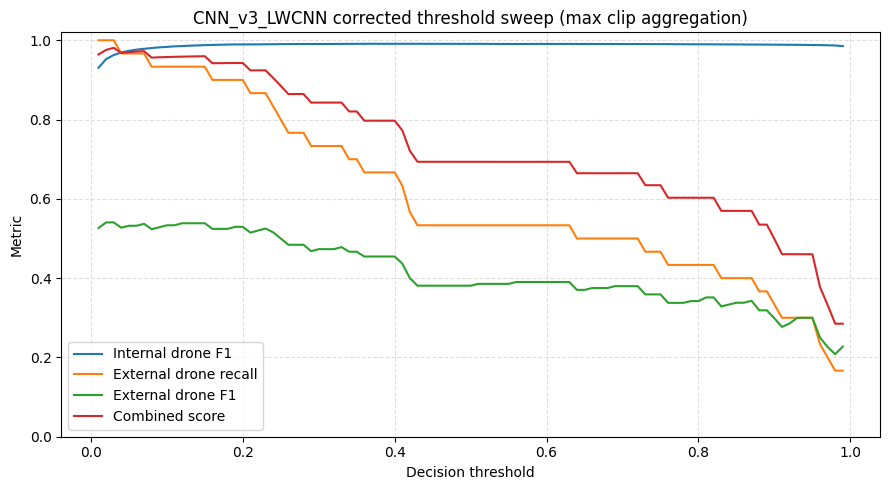

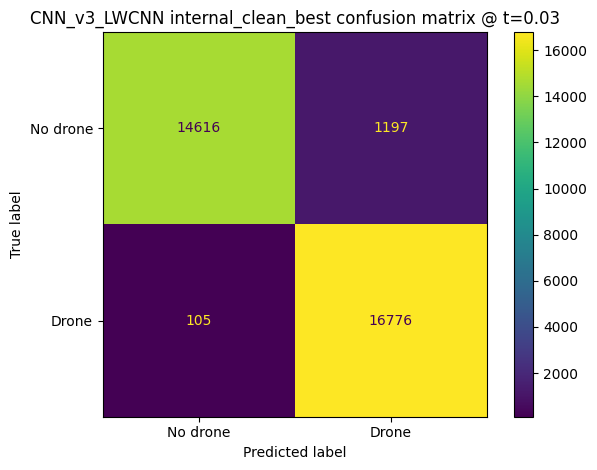

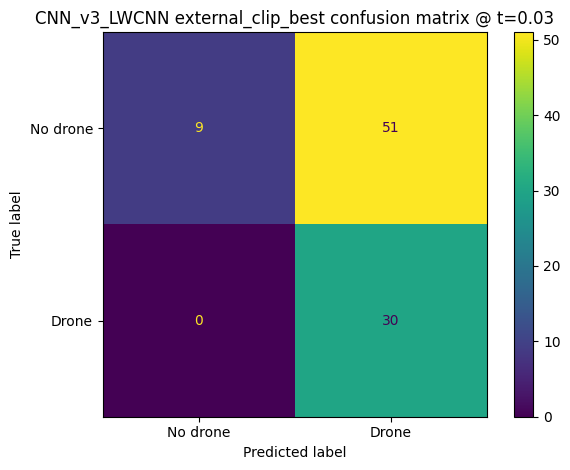

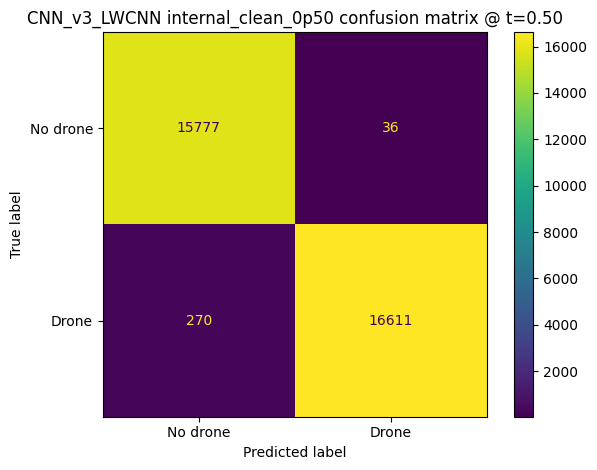

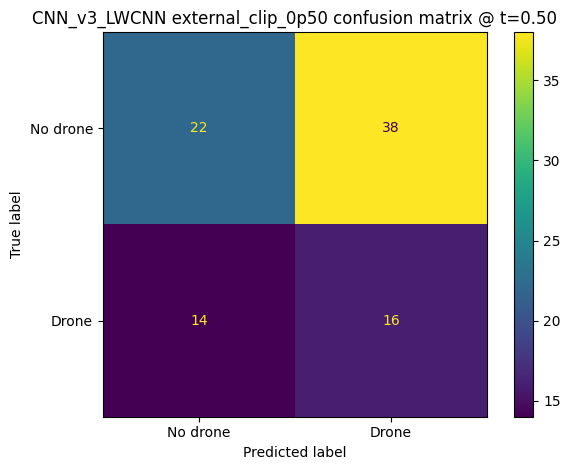

,model,model_path,parameters,input_shape,internal_clean_auc,external_clip_auc,external_clip_aggregation,best_threshold,best_internal_f1_drone,best_external_recall_drone,best_external_f1_drone,best_combined_score,t05_internal_f1_drone,t05_external_recall_drone,t05_external_f1_drone,sweep_csv,sweep_fig
0,CNN_v3_LWCNN,/content/drive/MyDrive/drone_audio_processed/m...,59649,"(None, 64, 63, 1)",0.99867,0.492778,max,0.03,0.962644,1.0,0.540541,0.980967,0.990873,0.533333,0.380952,/content/drive/MyDrive/drone_audio_processed/c...,/content/drive/MyDrive/drone_audio_processed/c...


In [9]:
all_summaries = []
all_sweeps = {}
loaded_models = {}

for model_name, model_path in MODEL_PATHS.items():
    if not model_path.exists():
        print(f'Skipping {model_name}: not found at {model_path}')
        continue

    print('\n' + '=' * 80)
    print(f'Loading {model_name}: {model_path}')
    try:
        model = load_keras_model(model_path)
    except Exception as e:
        print(f'ERROR: Could not load {model_name}: {e}')
        print('This v3-only notebook should only load model_lwcnn_drone_binary.keras. Check MODEL_PATHS above if this happens.')
        continue
    loaded_models[model_name] = model
    target_frames = get_target_frames(model)
    print('Model input shape:', model.input_shape, '| target frames:', target_frames)
    print('Total parameters:', model.count_params())

    y_int, p_int = predict_internal_or_load(model, model_name, target_frames)
    internal_auc = auc_safe(y_int, p_int)
    print(f'Internal clean AUC: {internal_auc:.6f}')

    ext_df = predict_external_or_load(model, model_name, target_frames)
    prob_col = f'prob_{CLIP_AGGREGATION}'
    y_ext = ext_df['binary_label'].to_numpy(dtype=int)
    p_ext = ext_df[prob_col].to_numpy(dtype=np.float32)
    external_auc = auc_safe(y_ext, p_ext)
    print(f'External clip AUC ({CLIP_AGGREGATION} aggregation): {external_auc:.6f}')

    sweep = threshold_sweep(y_int, p_int, y_ext, p_ext, thresholds=THRESHOLDS)
    sweep['model'] = model_name
    sweep['external_clip_aggregation'] = CLIP_AGGREGATION
    all_sweeps[model_name] = sweep
    sweep_path = RESULTS_DIR / f'{model_name}_corrected_threshold_sweep_{CLIP_AGGREGATION}.csv'
    sweep.to_csv(sweep_path, index=False)

    best_idx = sweep['combined_score_hmean_internal_f1_external_recall'].idxmax()
    best = sweep.loc[best_idx].copy()
    t_best = float(best['threshold'])
    print('Best threshold by combined score:', t_best)
    print(best[[
        'internal_f1_drone', 'external_recall_drone', 'external_f1_drone',
        'combined_score_hmean_internal_f1_external_recall',
        'internal_fp', 'internal_fn', 'external_fp', 'external_fn'
    ]])

    row_05 = sweep.iloc[(sweep['threshold'] - 0.50).abs().argmin()]

    sweep_fig = plot_sweep(sweep, model_name, RESULTS_DIR)
    save_confusion_matrix(y_int, p_int, t_best, model_name, 'internal_clean_best', RESULTS_DIR)
    save_confusion_matrix(y_ext, p_ext, t_best, model_name, 'external_clip_best', RESULTS_DIR)
    save_confusion_matrix(y_int, p_int, 0.50, model_name, 'internal_clean_0p50', RESULTS_DIR)
    save_confusion_matrix(y_ext, p_ext, 0.50, model_name, 'external_clip_0p50', RESULTS_DIR)

    all_summaries.append({
        'model': model_name,
        'model_path': str(model_path),
        'parameters': int(model.count_params()),
        'input_shape': str(model.input_shape),
        'internal_clean_auc': internal_auc,
        'external_clip_auc': external_auc,
        'external_clip_aggregation': CLIP_AGGREGATION,
        'best_threshold': t_best,
        'best_internal_f1_drone': float(best['internal_f1_drone']),
        'best_external_recall_drone': float(best['external_recall_drone']),
        'best_external_f1_drone': float(best['external_f1_drone']),
        'best_combined_score': float(best['combined_score_hmean_internal_f1_external_recall']),
        't05_internal_f1_drone': float(row_05['internal_f1_drone']),
        't05_external_recall_drone': float(row_05['external_recall_drone']),
        't05_external_f1_drone': float(row_05['external_f1_drone']),
        'sweep_csv': str(sweep_path),
        'sweep_fig': str(sweep_fig),
    })

summary_df = pd.DataFrame(all_summaries)
summary_path = RESULTS_DIR / f'corrected_results_summary_{CLIP_AGGREGATION}.csv'
summary_df.to_csv(summary_path, index=False)
summary_df

## 7. Thesis-ready tables

These are the tables to copy into the thesis. They are generated from the same saved prediction arrays as the confusion matrices and figures above.

In [10]:
if summary_df.empty:
    raise RuntimeError('No models were evaluated. Check MODEL_PATHS.')

print('Corrected summary table')
display(summary_df[[
    'model', 'parameters', 'internal_clean_auc', 'external_clip_auc',
    'best_threshold', 'best_internal_f1_drone', 'best_external_recall_drone',
    'best_external_f1_drone', 'best_combined_score',
    't05_internal_f1_drone', 't05_external_recall_drone', 't05_external_f1_drone'
]])

for model_name, sweep in all_sweeps.items():
    # Full report table: 0.05 to 0.95 in 0.05 increments
    thesis_thresholds = np.round(np.arange(0.05, 1.00, 0.05), 2)

    table = sweep[np.isin(np.round(sweep['threshold'].to_numpy(dtype=float), 2), thesis_thresholds)][[
        'threshold',
        'internal_f1_drone',
        'external_recall_drone',
        'external_f1_drone',
        'combined_score_hmean_internal_f1_external_recall',
        'internal_fp', 'internal_fn', 'external_fp', 'external_fn'
    ]].copy()

    table = table.sort_values('threshold').reset_index(drop=True)

    # Cleaner names for report copy/paste
    report_table = table.rename(columns={
        'threshold': 'Threshold',
        'internal_f1_drone': 'Internal Drone F1',
        'external_recall_drone': 'External Recall',
        'external_f1_drone': 'External Drone F1',
        'combined_score_hmean_internal_f1_external_recall': 'Combined Score',
        'internal_fp': 'Internal FP',
        'internal_fn': 'Internal FN',
        'external_fp': 'External FP',
        'external_fn': 'External FN',
    })

    table_path = RESULTS_DIR / f'{model_name}_threshold_table_0p05_to_0p95_full.csv'
    report_path = RESULTS_DIR / f'{model_name}_threshold_table_0p05_to_0p95_report.csv'

    table.to_csv(table_path, index=False)
    report_table.to_csv(report_path, index=False)

    print('\n' + '=' * 80)
    print(model_name, 'threshold table from 0.05 to 0.95')
    display(report_table.round(4))
    print('Saved full table:', table_path)
    print('Saved report table:', report_path)

    # Small copy/paste table with only the three columns you were using
    compact = report_table[['Threshold', 'Internal Drone F1', 'External Recall', 'External Drone F1']].copy()
    compact_path = RESULTS_DIR / f'{model_name}_compact_threshold_table_0p05_to_0p95.csv'
    compact.to_csv(compact_path, index=False)

    print('\nCompact table for report:')
    display(compact.round(4))
    print('Saved compact table:', compact_path)

Corrected summary table


,model,parameters,internal_clean_auc,external_clip_auc,best_threshold,best_internal_f1_drone,best_external_recall_drone,best_external_f1_drone,best_combined_score,t05_internal_f1_drone,t05_external_recall_drone,t05_external_f1_drone
0,CNN_v3_LWCNN,59649,0.99867,0.492778,0.03,0.962644,1.0,0.540541,0.980967,0.990873,0.533333,0.380952



CNN_v3_LWCNN threshold table from 0.05 to 0.95


,Threshold,Internal Drone F1,External Recall,External Drone F1,Combined Score,Internal FP,Internal FN,External FP,External FN
0,0.05,0.9733,0.9667,0.5321,0.9700,793,126,50,1
1,0.10,0.9833,0.9333,0.5333,0.9577,396,171,47,2
2,0.15,0.9877,0.9333,0.5385,0.9597,223,193,46,2
3,0.20,0.9895,0.9000,0.5294,0.9426,150,205,45,3
4,0.25,0.9903,0.8000,0.5000,0.8850,111,216,42,6
5,0.30,0.9906,0.7333,0.4731,0.8428,86,229,41,8
6,0.35,0.9910,0.7000,0.4667,0.8205,65,238,39,9
7,0.40,0.9911,0.6667,0.4545,0.7971,53,246,38,10
8,0.45,0.9910,0.5333,0.3810,0.6935,40,261,38,14
9,0.50,0.9909,0.5333,0.3810,0.6934,36,270,38,14


Saved full table: /content/drive/MyDrive/drone_audio_processed/corrected_cnn_v3_results_20260514_152348/CNN_v3_LWCNN_threshold_table_0p05_to_0p95_full.csv
Saved report table: /content/drive/MyDrive/drone_audio_processed/corrected_cnn_v3_results_20260514_152348/CNN_v3_LWCNN_threshold_table_0p05_to_0p95_report.csv

Compact table for report:


,Threshold,Internal Drone F1,External Recall,External Drone F1
0,0.05,0.9733,0.9667,0.5321
1,0.10,0.9833,0.9333,0.5333
2,0.15,0.9877,0.9333,0.5385
3,0.20,0.9895,0.9000,0.5294
4,0.25,0.9903,0.8000,0.5000
5,0.30,0.9906,0.7333,0.4731
6,0.35,0.9910,0.7000,0.4667
7,0.40,0.9911,0.6667,0.4545
8,0.45,0.9910,0.5333,0.3810
9,0.50,0.9909,0.5333,0.3810


Saved compact table: /content/drive/MyDrive/drone_audio_processed/corrected_cnn_v3_results_20260514_152348/CNN_v3_LWCNN_compact_threshold_table_0p05_to_0p95.csv
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## 8. Sanity checks that catch the old result errors

These checks are meant to prevent the same inconsistency appearing again.

In [11]:
for model_name, sweep in all_sweeps.items():
    row_05 = sweep.iloc[(sweep['threshold'] - 0.50).abs().argmin()]
    print(model_name)
    print('  Internal F1 @ 0.50 from sweep:', row_05['internal_f1_drone'])
    print('  External recall @ 0.50 from sweep:', row_05['external_recall_drone'])
    print('  External F1 @ 0.50 from sweep:', row_05['external_f1_drone'])

print('\nExternal binary label counts:')
print(ext_meta['binary_label'].value_counts().rename(index={0: 'non-drone', 1: 'drone'}))

if CLIP_AGGREGATION == 'max':
    for model_name in loaded_models:
        df = pd.read_csv(RESULTS_DIR / f'{model_name}_external_clip_predictions.csv')
        assert np.all(df['prob_max'] >= df['prob_mean'] - 1e-7), f'{model_name}: max aggregation check failed.'
print('\nSanity checks complete.')

CNN_v3_LWCNN
  Internal F1 @ 0.50 from sweep: 0.990873299928418
  External recall @ 0.50 from sweep: 0.5333333333333333
  External F1 @ 0.50 from sweep: 0.38095238095238093

External binary label counts:
binary_label
non-drone    60
drone        30
Name: count, dtype: int64

Sanity checks complete.


## 9. Optional: compare aggregation methods

This helps show why the old mean-vs-max mismatch matters. It does not change the primary thesis tables unless you change `CLIP_AGGREGATION` at the top and rerun.

In [12]:
agg_rows = []
for model_name in loaded_models:
    df = pd.read_csv(RESULTS_DIR / f'{model_name}_external_clip_predictions.csv')
    y_ext = df['binary_label'].to_numpy(dtype=int)
    for agg in ['mean', 'p95', 'top3_mean', 'max']:
        p_ext = df[f'prob_{agg}'].to_numpy(dtype=np.float32)
        auc = auc_safe(y_ext, p_ext)
        m05 = binary_metrics(y_ext, p_ext, 0.50)
        m30 = binary_metrics(y_ext, p_ext, 0.30)
        agg_rows.append({
            'model': model_name,
            'aggregation': agg,
            'external_auc': auc,
            'external_recall_t0p50': m05['recall_drone'],
            'external_f1_t0p50': m05['f1_drone'],
            'external_recall_t0p30': m30['recall_drone'],
            'external_f1_t0p30': m30['f1_drone'],
        })

agg_df = pd.DataFrame(agg_rows)
agg_path = RESULTS_DIR / 'external_aggregation_comparison.csv'
agg_df.to_csv(agg_path, index=False)
display(agg_df)
print('Saved:', agg_path)

,model,aggregation,external_auc,external_recall_t0p50,external_f1_t0p50,external_recall_t0p30,external_f1_t0p30
0,CNN_v3_LWCNN,mean,0.496111,0.133333,0.205128,0.200000,0.230769
1,CNN_v3_LWCNN,p95,0.465556,0.466667,0.358974,0.533333,0.390244
2,CNN_v3_LWCNN,top3_mean,0.474444,0.533333,0.400000,0.600000,0.418605
3,CNN_v3_LWCNN,max,0.492778,0.533333,0.380952,0.733333,0.473118


Saved: /content/drive/MyDrive/drone_audio_processed/corrected_cnn_v3_results_20260514_152348/external_aggregation_comparison.csv


## 10. Suggested thesis wording template

After running the notebook, fill the bracketed values from the generated summary and threshold tables.

> Using the corrected evaluation pipeline, random augmentation was disabled during validation and testing. Internal performance was computed on the held-out DADS window-level test set, while external performance was computed on the Svanström dataset at clip level using the maximum predicted drone probability across all 0.5 s windows. This corrected the earlier mismatch between the stated threshold-sweep protocol and the implementation, where window probabilities had been averaged and evaluation noise was applied stochastically. Under the corrected protocol, the best operating point for [MODEL] was threshold [T], giving internal drone F1 of [VALUE], external drone recall of [VALUE], external drone F1 of [VALUE], and combined score of [VALUE].

## Final output locations

After running the notebook, the threshold tables are saved inside the printed `RESULTS_DIR`, which will look like:

`/content/drive/MyDrive/drone_audio_processed/corrected_cnn_v3_results_YYYYMMDD_HHMMSS/`

Look for:

- `CNN_v3_LWCNN_compact_threshold_table_0p05_to_0p95.csv`
- `CNN_v3_LWCNN_threshold_table_0p05_to_0p95_report.csv`
- `CNN_v3_LWCNN_threshold_table_0p05_to_0p95_full.csv`